In [1]:
!pip install textblob

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

In [5]:
df = pd.read_csv('/content/Reviews.csv')
print(df.head())

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score          Time  \
0                   1.0                     1.0    5.0  1.303862e+09   
1                   0.0                     0.0    1.0  1.346976e+09   
2                   1.0                     1.0    4.0  1.219018e+09   
3                   3.0                     3.0    2.0  1.307923e+09   
4                   0.0                     0.0    5.0  1.350778e+09   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality cann

In [6]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [7]:
reviews = df['Text'].dropna()
print(reviews.head())

0    I have bought several of the Vitality canned d...
1    Product arrived labeled as Jumbo Salted Peanut...
2    This is a confection that has been around a fe...
3    If you are looking for the secret ingredient i...
4    Great taffy at a great price.  There was a wid...
Name: Text, dtype: object


In [8]:
def get_sentiment(text):

    analysis = TextBlob(str(text))

    if analysis.sentiment.polarity > 0:
        return 'Positive'

    elif analysis.sentiment.polarity < 0:
        return 'Negative'

    else:
        return 'Neutral'

In [9]:
df['Sentiment'] = reviews.apply(get_sentiment)
print(df[['Text', 'Sentiment']].head())

                                                Text Sentiment
0  I have bought several of the Vitality canned d...  Positive
1  Product arrived labeled as Jumbo Salted Peanut...  Negative
2  This is a confection that has been around a fe...  Positive
3  If you are looking for the secret ingredient i...  Positive
4  Great taffy at a great price.  There was a wid...  Positive


In [10]:
sentiment_counts = df['Sentiment'].value_counts()
print(sentiment_counts)

Sentiment
Positive    26525
Negative     2969
Neutral       446
Name: count, dtype: int64


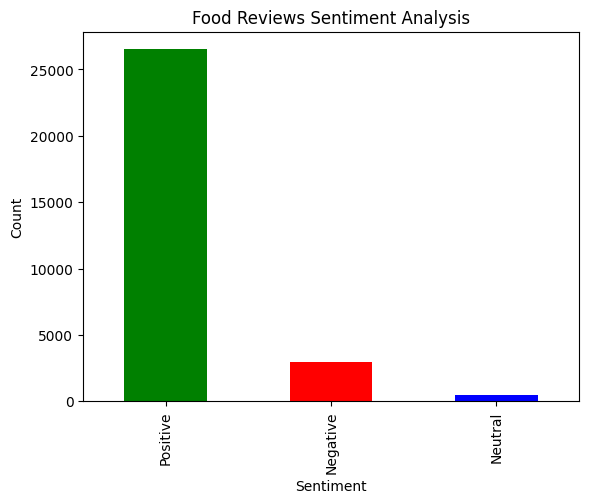

In [12]:
import matplotlib.pyplot as plt
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts.plot(
    kind='bar',
    color=['green', 'red', 'blue']
)
plt.title("Food Reviews Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [13]:
print("""
Conclusion:
1. Most food reviews are positive.
2. Sentiment analysis helps understand customer satisfaction.
3. NLP techniques classify customer opinions automatically.
4. Businesses can improve products based on customer feedback.
""")


Conclusion:
1. Most food reviews are positive.
2. Sentiment analysis helps understand customer satisfaction.
3. NLP techniques classify customer opinions automatically.
4. Businesses can improve products based on customer feedback.

